In [6]:
"""
# 01 — Introducción a las Redes Neuronales Convolucionales (CNNs)

Módulo: 05 — Deep Learning para Clasificación  
Framework: TensorFlow / Keras  
Dataset: Imágenes sintéticas (generadas en este notebook)

---

## ¿Qué vamos a aprender en este notebook?

1. Por qué el Perceptrón Multicapa (MLPs) no son ideales para imágenes
2. Qué es una convolución y cómo funciona intuitivamente
3. Los bloques que forman una CNN: Conv2D, Pooling, Flatten, Dense
4. Construir y visualizar nuestra primera CNN en Keras
5. Verificar que el modelo aprende algo coherente

---
## 1. El problema con el Perceptrón Multicapa para imágenes

Cuando usamos una red neuronal densa (MLP) sobre una imagen, lo primero que hacemos
es aplanarla (flatten): convertir una imagen de 28×28 píxeles en un vector de 784 números.

Esto tiene tres problemas serios:

| Problema | Descripción |
|---|---|
| Pérdida de estructura espacial | La relación entre píxeles vecinos desaparece |
| Demasiados parámetros | Una imagen de 128×128 con 3 canales → 49,152 entradas solo para la primera capa |
| No hay invarianza | El mismo objeto en distintas posiciones produce vectores completamente distintos |

Las CNNs resuelven los tres problemas a la vez.

## 2. ¿Qué es una convolución?

Una convolución es una operación matemática que desliza un filtro (también llamado
*kernel*) sobre la imagen y calcula un producto punto en cada posición.

Imagen original      Filtro (3×3)       Mapa de activación
┌───────────────┐   ┌─────────┐         ┌───────────┐
│ 0  1  0  1  0 │   │ 1  0 -1 │         │  2  0 -2  │
│ 1  1  1  0  1 │ * │ 2  0 -2 │    =    │  4  0 -4  │
│ 0  1  0  1  0 │   │ 1  0 -1 │         │  2  0 -2  │
│ 1  0  1  1  1 │   └─────────┘         └───────────┘
│ 0  1  0  0  1 │
└───────────────┘

Lo importante: el filtro es lo que la red aprende. No le decimos qué detectar,
aprende solo a detectar bordes, texturas, formas, etc.

### Ventajas clave
- Compartición de pesos: el mismo filtro se aplica en toda la imagen → muchos menos parámetros
- Localidad: cada neurona solo ve una región pequeña de la imagen
- Composición jerárquica: capas tempranas detectan bordes, capas profundas detectan objetos

## 3. Bloques fundamentales de una CNN

### 3.1 Capa Convolucional — Conv2D
Aplica N filtros sobre la imagen. Cada filtro produce un mapa de características (feature map).

python
Conv2D(filters=32, kernel_size=(3,3), activation='relu')


### 3.2 Capa de Pooling — MaxPooling2D
Reduce el tamaño espacial tomando el valor máximo de cada región.
Aporta invarianza a pequeñas traslaciones.

Antes del pooling (4×4)    Después MaxPool 2×2 (2×2)
┌────────────────┐          ┌──────────┐
│  1   3  2   4  │          │  3   4   │
│  5   6  7   8  │   →      │  9  11   │
│  3   2  1   0  │          └──────────┘
│  9  10  11  6  │
└────────────────┘

### 3.3 Flatten + Dense
Una vez extraídas las características, se aplana el tensor y se conecta
a capas densas para la clasificación final.

### 3.4 Arquitectura típica

Input → [Conv2D → ReLU → MaxPool] × N → Flatten → Dense → Softmax → Output
"""

"\n# 01 — Introducción a las Redes Neuronales Convolucionales (CNNs)\n\nMódulo: 05 — Deep Learning para Clasificación  \nFramework: TensorFlow / Keras  \nDataset: Imágenes sintéticas (generadas en este notebook)\n\n---\n\n## ¿Qué vamos a aprender en este notebook?\n\n1. Por qué el Perceptrón Multicapa (MLPs) no son ideales para imágenes\n2. Qué es una convolución y cómo funciona intuitivamente\n3. Los bloques que forman una CNN: Conv2D, Pooling, Flatten, Dense\n4. Construir y visualizar nuestra primera CNN en Keras\n5. Verificar que el modelo aprende algo coherente\n\n---\n## 1. El problema con el Perceptrón Multicapa para imágenes\n\nCuando usamos una red neuronal densa (MLP) sobre una imagen, lo primero que hacemos\nes aplanarla (flatten): convertir una imagen de 28×28 píxeles en un vector de 784 números.\n\nEsto tiene tres problemas serios:\n\n| Problema | Descripción |\n|---|---|\n| Pérdida de estructura espacial | La relación entre píxeles vecinos desaparece |\n| Demasiados paráme

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.21.0
Keras version: 3.14.0


In [8]:
"""
## 5. Dataset sintético

Vamos a generar imágenes sintéticas de formas geométricas simples:
círculos y cuadrados. Esto nos permite:

- Controlar exactamente los datos
- Entender qué aprende la red sin ambigüedad
- No depender de ninguna descarga externa
"""

'\n## 5. Dataset sintético\n\nVamos a generar imágenes sintéticas de formas geométricas simples:\ncírculos y cuadrados. Esto nos permite:\n\n- Controlar exactamente los datos\n- Entender qué aprende la red sin ambigüedad\n- No depender de ninguna descarga externa\n'

In [9]:
def generate_circle(img_size=32):
    """Genera una imagen con un círculo blanco sobre fondo negro."""
    img = np.zeros((img_size, img_size), dtype=np.float32)
    cx = np.random.randint(8, img_size - 8)
    cy = np.random.randint(8, img_size - 8)
    r  = np.random.randint(4, 10)
    for i in range(img_size):
        for j in range(img_size):
            if (i - cy)**2 + (j - cx)**2 <= r**2:
                img[i, j] = 1.0
    return img

def generate_square(img_size=32):
    """Genera una imagen con un cuadrado blanco sobre fondo negro."""
    img = np.zeros((img_size, img_size), dtype=np.float32)
    side = np.random.randint(6, 14)
    x0   = np.random.randint(2, img_size - side - 2)
    y0   = np.random.randint(2, img_size - side - 2)
    img[y0:y0+side, x0:x0+side] = 1.0
    return img

def generate_dataset(n_samples=1000, img_size=32):
    """Genera n_samples imágenes balanceadas: mitad círculos, mitad cuadrados."""
    X, y = [], []
    for _ in range(n_samples // 2):
        X.append(generate_circle(img_size))
        y.append(0)  # 0 = círculo
    for _ in range(n_samples // 2):
        X.append(generate_square(img_size))
        y.append(1)  # 1 = cuadrado
    X = np.array(X)[..., np.newaxis]  # Agregar canal: (N, 32, 32, 1)
    y = np.array(y)
    # Shuffle
    idx = np.random.permutation(len(X))
    return X[idx], y[idx]

# Generar datos
X, y = generate_dataset(n_samples=2000)

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"Clases: {np.unique(y)} — 0=círculo, 1=cuadrado")
print(f"Balance: {np.sum(y==0)} círculos | {np.sum(y==1)} cuadrados")

Shape de X: (2000, 32, 32, 1)
Shape de y: (2000,)
Clases: [0 1] — 0=círculo, 1=cuadrado
Balance: 1000 círculos | 1000 cuadrados


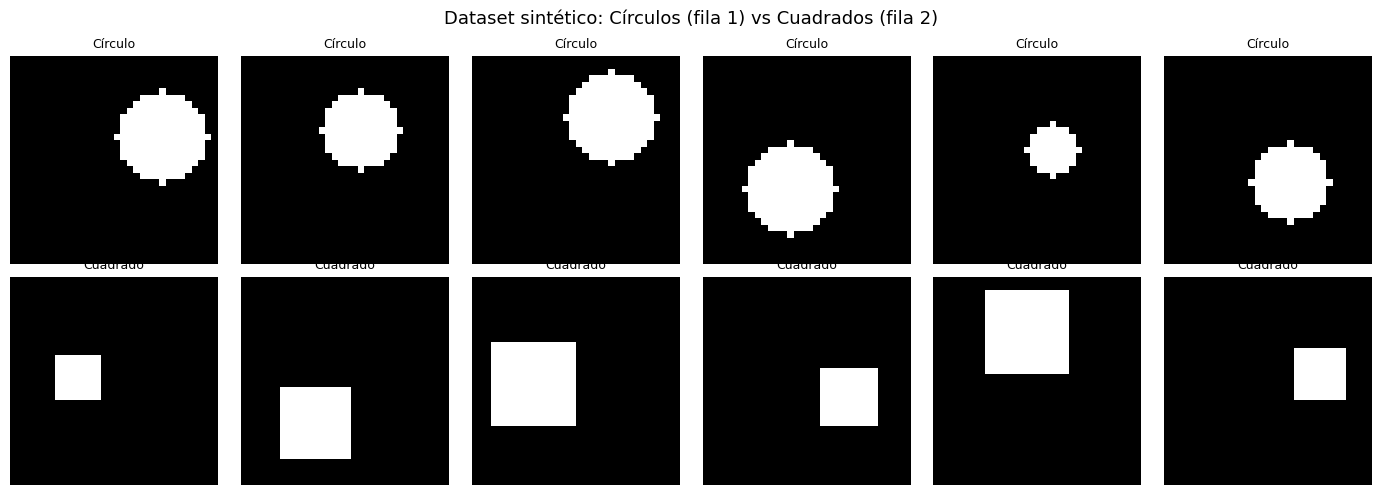

In [10]:
# Visualizar algunas muestras
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('Dataset sintético: Círculos (fila 1) vs Cuadrados (fila 2)', fontsize=13)

circulos  = X[y == 0]
cuadrados = X[y == 1]

for i in range(6):
    axes[0, i].imshow(circulos[i, :, :, 0], cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title('Círculo', fontsize=9)

    axes[1, i].imshow(cuadrados[i, :, :, 0], cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title('Cuadrado', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/01_dataset_sintetico.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
"""
## 6. División train / validation / test

Dividimos el dataset en tres partes:

| Conjunto | Proporción | Para qué sirve |
|---|---|---|
| Train | 70% | Entrenar el modelo |
| Validation | 15% | Monitorear durante el entrenamiento |
| Test | 15% | Evaluación final — el modelo nunca lo vio |

El conjunto de validación nos permite detectar overfitting durante el entrenamiento sin tocar el test set.
"""

'\n## 6. División train / validation / test\n\nDividimos el dataset en tres partes:\n\n| Conjunto | Proporción | Para qué sirve |\n|---|---|---|\n| Train | 70% | Entrenar el modelo |\n| Validation | 15% | Monitorear durante el entrenamiento |\n| Test | 15% | Evaluación final — el modelo nunca lo vio |\n\nEl conjunto de validación nos permite detectar overfitting durante el entrenamiento sin tocar el test set.\n'

In [12]:
from sklearn.model_selection import train_test_split

# 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Val:   {X_val.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

Train: 1400 muestras
Val:   300 muestras
Test:  300 muestras


In [ ]:
"""
Dragonfly 3D

## 7. Nuestra primera CNN en Keras

Vamos a construir una CNN simple con "dos bloques convolucionales"
seguidos de capas densas.
Input (32×32×1)
↓
Conv2D(16, 3×3) → ReLU
↓
MaxPooling2D(2×2)   → output: 16×16×16
↓
Conv2D(32, 3×3) → ReLU
↓
MaxPooling2D(2×2)   → output: 8×8×32
↓
Flatten             → output: 2048
↓
Dense(64) → ReLU
↓
Dense(1) → Sigmoid  → output: probabilidad de ser cuadrado

Usamos Sigmoid en la última capa porque es clasificación binaria (círculo o cuadrado). Si tuviéramos más de 2 clases usaríamos "Softmax".

"""